<center>
<img src="https://raw.githubusercontent.com/FUlyankin/r_probability/master/end_seminars_2020/sem08/real_expect.png" width="800">

# Домашнее задание 3: Аварии на шахтах
</center>

## Общая информация

__Дата выдачи:__ 14.03.2026

__Дедлайн:__ 23:59MSK 05.04.2026

In [1]:
import math

import numpy as np

import scipy.stats as sts
from scipy.stats import norm
import matplotlib.pyplot as plt
import math

plt.style.use('ggplot')  # стиль для графиков
%matplotlib inline

На угольных шахтах ежегодно происходят аварии. Англия довольно давно собирает информацию о числе крупных аварий. Именно её нам предстоит проанализировать:

* хочется понять как часто в среднем происходят аварии 
* насколько большой у среднего числа аварий доверительный интервал

In [2]:
import pandas as pd

df = pd.read_csv("coals.csv", index_col=0)
df.head()

,year,count
1,1851,4
2,1852,5
3,1853,4
4,1854,1
5,1855,0


В колонке `year` находится год наблюдений. В колонке `count` число аварий за этот год на шахтах в Англии. Посмотрим на распределение числа аварий. 

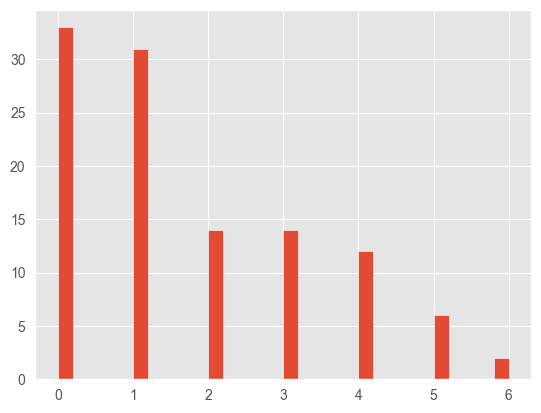

In [3]:
df['count'].hist(bins=30);

Судя по гистограмме уместно предположить, что число аварий имеет распределение Пуассона, $Poiss(\lambda)$.  То есть, если мы хотим что-то понять про среднее число аварий, нам надо оценить параметр $\lambda$. 

__а) Метод моментов__

Найдите оценку параметра $\lambda$ с помощью метода моментов. Запишите получившийся результат в переменную `lambda_hat`.

In [4]:
n_hat = df.shape[0]   # число наблюдений 
lambda_hat = 1/n_hat*df['count'].sum()     # оценка метода моментов
print(lambda_hat)


1.7053571428571428


__б) Стандартное отклонение__ 

Среднее, оценённое методом моментов будет иметь асимптотически нормальное распределение. Оцените стандартное отклонение этого распределения по выборке и запишите ответ в переменную `lam_se`. 

> __Примечание:__ мы предполагаем, что выборка пришла из распределения Пуассона. Для него $Var(X) = \lambda$. Для оценки стандартного отклонения используйте этот факт. Конечно же вы можете оценить его через функцию `std`, в плане асимптотики результат получится одинаковый. Оба способа корректны. Но с точки зрения грейдера, у вас будет ошибка. 

In [5]:
lam_se = (lambda_hat/n_hat)**0.5     # оценка стандратного отклонения
print(lam_se)

0.1233953121525469


__в) Доверительный интервал__ 

Постройте для неизвестного математического ожидания $\lambda$ доверительный интервал. Возьмите уровень значимости равный $10\%$. В переменные `left` и `right` запишите соотвествующие границы интервала. В переменную `delta` запишите его ширину.

In [6]:
alpha = 0.1
z = norm.ppf(1-alpha/2)

left = lambda_hat - z*lam_se
right = lambda_hat + z*lam_se
delta = right - left

print(f"Правая граница: {right}")
print(f'Левая граница: {left}')
print(f"Ширина доверительного интервала: {delta}")

Правая граница: 1.9083243696000687
Левая граница: 1.502389916114217
Ширина доверительного интервала: 0.4059344534858518


__г) Число катастроф__  

Многие говорят, что в $20$ веке катастроф стало на порядок меньше. Давайте проверим это. Постройте оценку для $\lambda_1$ по данным до $1900$ года включительно. Постройте оценку для $\lambda_2$ по данным после $1900$ года. Для разности $\lambda_1 - \lambda_2$ постройте $95\%$ доверительный интервал.

In [7]:
x = df[df.year <= 1900]['count']
y = df[df.year > 1900]['count']

lambda_hat_1 = x.mean()
lambda_hat_2 = y.mean()
difference = lambda_hat_1 - lambda_hat_2

diff_se = (lambda_hat_1/len(x)+lambda_hat_2/len(y))**0.5

alpha = 0.05
z = norm.ppf(1-alpha/2)

left = difference - z*diff_se
right = difference + z*diff_se
delta = right - left

print(f"Правая граница: {right}")
print(f'Левая граница: {left}')
print(f"Ширина доверительного интервала: {delta}")


Правая граница: 2.3100010011251353
Левая граница: 1.2835473859716393
Ширина доверительного интервала: 1.026453615153496


Ноль не вошёл в этот доверительный интервал. Это означает, что на уровне значимости $5\%$ мы можем сказать, что число аварий правда снизилось. 

__д) Вероятность для распределения Пуассона__ 

Вспомните формулу, по которой считается вероятность того, что Пуассоновская случайная величина примет какое-то значение. Найдите точечную оценку вероятности того, что произойдёт только одна авария. В качестве $\lambda$ используйте оценку метода моментов, полученную в первом задании. 

In [8]:
def poiss_prob(m):
    return(lambda_hat**m*math.exp(-lambda_hat))/math.factorial(m)
print(poiss_prob(1))

0.3098761473208731


__е) Дельта-метод__ 

Та вероятность, которую мы нашли в предыдущем пункте - это лишь точечная оценка. Она является функцией от среднего. С помощью дельта-метода постройте для этой вероятности $95\%$ довертельный интервал.

In [9]:
#Найдем стандратное отклонение функции (формула для поиска вероятности пуассоновской СВ):
g = lambda_hat*math.exp(-lambda_hat)
g_deriv = math.exp(-lambda_hat)-lambda_hat*math.exp(-lambda_hat)
g_se = abs(g_deriv) *  lam_se

#Доверительный интервал
alpha = 0.05
z = norm.ppf(1 - alpha/2)

left = g - z*g_se
right = g + z*g_se
delta = right - left

print(f"Правая граница: {right}")
print(f'Левая граница: {left}')
print(f"Ширина доверительного интервала: {delta}")


Правая граница: 0.34087378686549136
Левая граница: 0.27887850777625484
Ширина доверительного интервала: 0.06199527908923652


По аналогии можно построить доверительные интервалы для вероятности того, что случайная величина примет значения от нуля до девяти. Проделайте это в качестве необязательного упражнения и оформите процедуру расчёта в виде функции.

In [10]:
def prob_ci(m, alpha = 0.01, lam_hat=lambda_hat):
    g = lambda_hat**m*math.exp(-lambda_hat)/math.factorial(m)

    #Производная функции по lambda_hat
    if m==0:
        g_deriv = -math.exp(-lambda_hat)
    else:
        g_deriv = math.exp(-lambda_hat) * (lam_hat**(m-1)) * (m - lam_hat) / math.factorial(m)

    #Стандратное отклонение функции
    g_se = abs(g_deriv) * lam_se

    # квантиль нормального распределения
    z = norm.ppf(1 - alpha/2)

    left = g - z * g_se
    right = g + z * g_se
    return left, right

In [11]:
left, right = prob_ci(1)
delta = right - left

assert np.abs(delta - 0.08147) < 1e-5

left, right = prob_ci(0)
delta = right - left

assert np.abs(delta - 0.11551) < 1e-5

Сделали функцию? Запускайте код для не очень информативной картинки!

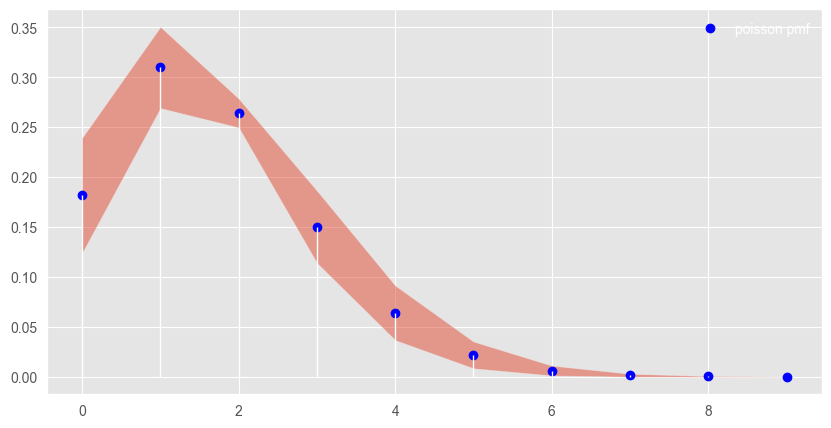

In [12]:
poiss_rv = sts.poisson(lambda_hat)

x = np.arange(10)

p = poiss_rv.pmf(x)

left = np.array([prob_ci(m)[0] for m in x])
right = np.array([prob_ci(m)[1] for m in x])

plt.figure(figsize=(10,5))
plt.plot(x, p, 'bo', ms=6, label='poisson pmf')
plt.fill_between(x, left, right, alpha=0.5)
plt.vlines(x, 0, p, lw=1)
plt.legend(loc='best', frameon=False)
plt.show()

In [13]:
for k,(i,j) in enumerate(zip(left, right)):
    print(f"Вероятность P(X={k}) лежит между  {i:.5} и {j:.5}")

Вероятность P(X=0) лежит между  0.12395 и 0.23946
Вероятность P(X=1) лежит между  0.26914 и 0.35061
Вероятность P(X=2) лежит между  0.24971 и 0.27873
Вероятность P(X=3) лежит между  0.11396 и 0.18644
Вероятность P(X=4) лежит между  0.036649 и 0.091422
Вероятность P(X=5) лежит между  0.0084293 и 0.035252
Вероятность P(X=6) лежит между  0.0012388 и 0.011177
Вероятность P(X=7) лежит между  1.9936e-05 и 0.0030047
Вероятность P(X=8) лежит между  -5.5837e-05 и 0.00070061
Вероятность P(X=9) лежит между  -2.1966e-05 и 0.00014414


Интервалы получился довольно короткими. Попробуйте поиграться с уровнем значимости и посмотреть как они меняются в зависимости от него. 

В этой терадке нам осталось обсудить последний нюанс. Мы из теории вероятностей знаем, что для случайной величины $X$, имеющей распределение Пуассона $\mathbb{E}(X) = Var(X) = \lambda$. Для текущей выборки мы видим, что между дисперсией и средним есть небольшое отличие. 

In [14]:
df['count'].mean()

np.float64(1.7053571428571428)

In [15]:
df['count'].var()

np.float64(2.714205276705277)

Не факт, что мы имеем право предполагать, что наша выборка пришла к нам из распределения Пуассона. Все предпосылки о распределениях выборки нужно тестировать. Позже мы научимся это делать.